In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
from scipy.io import loadmat
from scipy.interpolate import griddata
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
def prepare_lut_for_fitting(pmsm_lut: dict):
    id_vec = np.asarray(pmsm_lut["i_d_vec"]).ravel()
    iq_vec = np.asarray(pmsm_lut["i_q_vec"]).ravel()

    def fill_nans(arr2d):
        arr = arr2d.copy().astype(float)
        xi, yi = np.indices(arr.shape)
        mask = np.isnan(arr)
        if mask.any():
            arr[mask] = griddata(
                (xi[~mask], yi[~mask]), arr[~mask],
                (xi[mask],  yi[mask]),  method="nearest"
            )
        return arr

    psi_d_raw = fill_nans(np.asarray(pmsm_lut["Psi_d"]))
    psi_q_raw = fill_nans(np.asarray(pmsm_lut["Psi_q"]))
    L_dd_raw  = fill_nans(np.asarray(pmsm_lut["L_dd"]))
    L_dq_raw  = fill_nans(np.asarray(pmsm_lut["L_dq"]))
    L_qd_raw  = fill_nans(np.asarray(pmsm_lut["L_qd"]))
    L_qq_raw  = fill_nans(np.asarray(pmsm_lut["L_qq"]))

    psi_d_max = float(np.max(np.abs(psi_d_raw)))
    psi_q_max = float(np.max(np.abs(psi_q_raw)))
    i_max     = float(max(np.max(np.abs(id_vec)), np.max(np.abs(iq_vec))))
    L_dd_max  = float(np.max(np.abs(L_dd_raw)))
    L_qq_max  = float(np.max(np.abs(L_qq_raw)))
    L_dq_max  = float(np.max(np.abs(L_dq_raw)))   
    L_qd_max  = float(np.max(np.abs(L_qd_raw))) 

    norm = dict(
        psi_d_max=psi_d_max, psi_q_max=psi_q_max,
        L_dd_max=L_dd_max,   L_qq_max=L_qq_max,
        L_dq_max=L_dq_max,   L_qd_max=L_qd_max,
        i_max=i_max,
    )

    id_grid_pu = jnp.array(id_vec / i_max)
    iq_grid_pu = jnp.array(iq_vec / i_max)
    id_grid_A  = jnp.array(id_vec)
    iq_grid_A  = jnp.array(iq_vec)

    luts_pu = dict(
        psi_d=jnp.array(psi_d_raw.T / psi_d_max),
        psi_q=jnp.array(psi_q_raw.T / psi_q_max),
        L_dd =jnp.array(L_dd_raw.T  / L_dd_max),
        L_dq =jnp.array(L_dq_raw.T  / L_dq_max),
        L_qd =jnp.array(L_qd_raw.T  / L_qd_max),  
        L_qq =jnp.array(L_qq_raw.T  / L_qq_max),
    )
    luts_phys = dict(
        psi_d=jnp.array(psi_d_raw.T), psi_q=jnp.array(psi_q_raw.T),
        L_dd =jnp.array(L_dd_raw.T),  L_dq =jnp.array(L_dq_raw.T),
        L_qd =jnp.array(L_qd_raw.T),  L_qq =jnp.array(L_qq_raw.T),
    )
    return id_grid_pu, iq_grid_pu, id_grid_A, iq_grid_A, luts_pu, luts_phys, norm


notebook_dir = Path.cwd().parent
lut_raw = loadmat(notebook_dir / "exciting_environments/pmsm/LUT_BRUSA_jax_grad.mat")
id_grid_pu, iq_grid_pu, id_grid_A, iq_grid_A, luts_pu, luts_phys, norm = prepare_lut_for_fitting(lut_raw)

2026-04-23 10:09:16.268842: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.6.77). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:

def algebraic_sigmoid(z, beta):
    return z / jnp.sqrt(z**2 + beta)


def softmax_activation(z, beta):
    scaled = beta * z
    shifted = scaled - jnp.max(scaled)
    exp_z   = jnp.exp(shifted)
    return exp_z / jnp.sum(exp_z)


def pnorm_gradient(z, beta, p=8):
    bz   = beta * z
    bz_p = bz ** p                       
    S    = 1.0 + jnp.sum(bz_p)           
    exp  = (1.0 / p) - 1.0
    return S**exp * bz**(p - 1) * beta     

class GradientNetworkFlux(eqx.Module):

    A    : jax.Array   
    b    : jax.Array   
    A0_d : jax.Array   
    A0_q : jax.Array   
    b0   : jax.Array   
    log_beta : jax.Array 

    psi_d_max : jax.Array
    psi_q_max : jax.Array
    i_max     : jax.Array

    N                 : int  = eqx.field(static=True)
    activation        : str  = eqx.field(static=True) 
    p_order           : int  = eqx.field(static=True) 
    enforce_q_symmetry: bool = eqx.field(static=True)

    def __init__(
        self,
        key,
        norm,
        N=12,
        activation='pnorm',   # 'sigmoid' | 'softmax' | 'pnorm'
        p_order=8,
        enforce_q_symmetry=True,
    ):
        self.N                  = N
        self.activation         = activation
        self.p_order            = p_order
        self.enforce_q_symmetry = enforce_q_symmetry

        self.psi_d_max = jnp.array(norm["psi_d_max"])
        self.psi_q_max = jnp.array(norm["psi_q_max"])
        self.i_max     = jnp.array(norm["i_max"])

        keys = jax.random.split(key, 4)

        self.A       = jax.random.normal(keys[0], (N, 2)) * 0.1
        self.b       = jax.random.normal(keys[1], (N,))   * 0.1
        self.b0      = jnp.zeros(2)
        self.A0_d    = jnp.array(0.1)
        self.A0_q    = jnp.array(0.1)
        self.log_beta = jnp.array(0.0)   

    def _core(self, x):
        beta = jnp.exp(self.log_beta)
        z    = self.A @ x + self.b             

        if self.activation == 'sigmoid':
            sigma = algebraic_sigmoid(z, beta) 
        elif self.activation == 'softmax':
            sigma = softmax_activation(z, beta)
        else:  
            sigma = pnorm_gradient(z, beta, self.p_order) 
        linear = jnp.array([
            self.A0_d * x[0],
            self.A0_q * x[1],
        ])

        return linear + self.b0 + self.A.T @ sigma 
    
    def _symmetrized(self, x):
        C   = jnp.array([1.0, -1.0])
        gx  = self._core(x)
        gCx = self._core(C * x) * C  
        return 0.5 * (gx + gCx)

    def _g(self, x):
        if self.enforce_q_symmetry:
            return self._symmetrized(x)
        return self._core(x)

    def __call__(self, id_pu, iq_pu):
        x = jnp.array([id_pu, iq_pu])
        out = self._g(x)
        return out[0], out[1] 

    def flux_physical(self, id_A, iq_A):
        id_pu = id_A / self.i_max
        iq_pu = iq_A / self.i_max
        psi_d_pu, psi_q_pu = self(id_pu, iq_pu)
        return psi_d_pu * self.psi_d_max, psi_q_pu * self.psi_q_max

    def inductances_physical(self, id_A, iq_A):
        id_pu = id_A / self.i_max
        iq_pu = iq_A / self.i_max

        jac = jax.jacobian(
            lambda i: jnp.stack(self(i[0], i[1]))
        )(jnp.stack([id_pu, iq_pu]))

        scale_d = self.psi_d_max / self.i_max
        scale_q = self.psi_q_max / self.i_max

        L_dd = jac[0, 0] * scale_d
        L_qq = jac[1, 1] * scale_q
        L_dq = jac[0, 1] * scale_d
        L_qd = jac[1, 0] * scale_q  

        return L_dd, L_qq, L_dq, L_qd

## Training


In [5]:
def eval_grid(model, id_grid, iq_grid):
    return jax.vmap(
        jax.vmap(model, (None, 0)),
        (0, None)
    )(id_grid, iq_grid)

def train_gradient_network(
    model,
    id_grid,
    iq_grid,
    psi_d_lut,
    psi_q_lut,
    norm,
    L_dd_lut=None,
    L_qq_lut=None,
    L_dq_lut=None,
    L_qd_lut=None,
    w_psi=1.0,
    w_L=0.1,
    lr=1e-3,
    n_steps=30_000,
    print_every=3_000,
):
    use_L = (L_dd_lut is not None)

    norm_L_dd = jnp.array(norm["L_dd_max"])
    norm_L_qq = jnp.array(norm["L_qq_max"])
    norm_L_dq = jnp.array(norm["L_dq_max"])
    norm_L_qd = jnp.array(norm["L_qd_max"])  

    opt       = optax.adam(lr)
    opt_state = opt.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    @eqx.filter_value_and_grad
    def loss_fn(m):
        psi_d_hat, psi_q_hat = eval_grid(m, id_grid, iq_grid)
        loss_psi = (
            jnp.mean((psi_d_hat - psi_d_lut) ** 2) +
            jnp.mean((psi_q_hat - psi_q_lut) ** 2)
        )

        if not use_L:
            return w_psi * loss_psi

        def jac_scaled(id_pu, iq_pu):
            jac = jax.jacobian(
                lambda i: jnp.stack(m(i[0], i[1]))
            )(jnp.array([id_pu, iq_pu]))
            Ldd = jac[0, 0] * (m.psi_d_max / m.i_max) / norm_L_dd
            Lqq = jac[1, 1] * (m.psi_q_max / m.i_max) / norm_L_qq
            Ldq = jac[0, 1] * (m.psi_d_max / m.i_max) / norm_L_dq
            Lqd = jac[1, 0] * (m.psi_q_max / m.i_max) / norm_L_qd  
            return Ldd, Lqq, Ldq, Lqd

        Ldd_hat, Lqq_hat, Ldq_hat, Lqd_hat = jax.vmap(
            jax.vmap(jac_scaled, (None, 0)), (0, None)
        )(id_grid, iq_grid)

        loss_L = (
            jnp.mean((Ldd_hat - L_dd_lut) ** 2) +
            jnp.mean((Lqq_hat - L_qq_lut) ** 2) +
            jnp.mean((Ldq_hat - L_dq_lut) ** 2) +
            jnp.mean((Lqd_hat - L_qd_lut) ** 2)
        )

        return w_psi * loss_psi + w_L * loss_L

    for i in range(n_steps):
        loss_val, grads = loss_fn(model)
        updates, opt_state = opt.update(
            eqx.filter(grads, eqx.is_array), opt_state
        )
        model = eqx.apply_updates(model, updates)
        if i % print_every == 0 or i == n_steps - 1:
            print(f"  step {i:5d}   loss = {float(loss_val):.4e}")

    return model

def approximation_error(model, id_grid_A, iq_grid_A, luts_phys,
                        with_L=False):

    psi_d_hat, psi_q_hat = jax.vmap(
        jax.vmap(model.flux_physical, (None, 0)), (0, None)
    )(id_grid_A, iq_grid_A)

    eps_d = jnp.abs(psi_d_hat - luts_phys["psi_d"]) / jnp.max(jnp.abs(luts_phys["psi_d"])) * 100.0
    eps_q = jnp.abs(psi_q_hat - luts_phys["psi_q"]) / jnp.max(jnp.abs(luts_phys["psi_q"])) * 100.0

    print(f"  max psi_d error = {eps_d.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_d**2)):.2f}%")
    print(f"  max psi_q error = {eps_q.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_q**2)):.2f}%")

    if not with_L:
        return eps_d, eps_q

    Ldd_hat, Lqq_hat, Ldq_hat, Lqd_hat = jax.vmap(
        jax.vmap(model.inductances_physical, (None, 0)), (0, None)
    )(id_grid_A, iq_grid_A)

    eps_Ldd = jnp.abs(Ldd_hat - luts_phys["L_dd"]) / jnp.max(jnp.abs(luts_phys["L_dd"])) * 100.0
    eps_Lqq = jnp.abs(Lqq_hat - luts_phys["L_qq"]) / jnp.max(jnp.abs(luts_phys["L_qq"])) * 100.0
    eps_Ldq = jnp.abs(Ldq_hat - luts_phys["L_dq"]) / jnp.max(jnp.abs(luts_phys["L_dq"])) * 100.0
    eps_Lqd = jnp.abs(Lqd_hat - luts_phys["L_qd"]) / jnp.max(jnp.abs(luts_phys["L_qd"])) * 100.0

    print(f"  max L_dd error  = {eps_Ldd.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_Ldd**2)):.2f}%")
    print(f"  max L_qq error  = {eps_Lqq.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_Lqq**2)):.2f}%")
    print(f"  max L_dq error  = {eps_Ldq.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_Ldq**2)):.2f}%")
    print(f"  max L_qd error  = {eps_Lqd.max():.2f}%   rms = {jnp.sqrt(jnp.mean(eps_Lqd**2)):.2f}%")

    return eps_d, eps_q, eps_Ldd, eps_Lqq, eps_Ldq, eps_Lqd

In [7]:
key = jax.random.PRNGKey(42)

model_gn = GradientNetworkFlux(
    key,
    norm,
    N=12,                       
    activation='pnorm',         
    p_order=8,
    enforce_q_symmetry=False,   
)

print(f"Trainable Parameters: {sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model_gn, eqx.is_array)))}")

model_gn_psi_only = train_gradient_network(
    model_gn,
    id_grid_pu,
    iq_grid_pu,
    luts_pu["psi_d"],
    luts_pu["psi_q"],
    norm,
    lr=1e-3,
    n_steps=30_000,
    print_every=5_000,
)

eps_d, eps_q, eps_Ldd, eps_Lqq, eps_Ldq, eps_Lqd = approximation_error(
    model_gn_psi_only, id_grid_A, iq_grid_A,
    luts_phys,with_L=True
)


Trainable Parameters: 44
  step     0   loss = 7.4200e-01
  step  5000   loss = 2.4018e-04
  step 10000   loss = 1.9320e-04
  step 15000   loss = 1.5777e-04
  step 20000   loss = 1.5574e-04
  step 25000   loss = 1.5570e-04
  step 29999   loss = 1.5557e-04
  max psi_d error = 2.70%   rms = 0.84%
  max psi_q error = 3.29%   rms = 0.92%
  max L_dd error  = 18.82%   rms = 3.13%
  max L_qq error  = 11.41%   rms = 2.90%
  max L_dq error  = 60.74%   rms = 11.92%
  max L_qd error  = 89.24%   rms = 18.51%


In [8]:
key = jax.random.PRNGKey(42)

model_gn = GradientNetworkFlux(
    key,
    norm,
    N=12,                       
    activation='pnorm',         
    p_order=8,
    enforce_q_symmetry=False,   
)

print(f"Trainable Parameters: {sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model_gn, eqx.is_array)))}")


model_gn_with_L = train_gradient_network(
    model_gn, id_grid_pu, iq_grid_pu,
    luts_pu["psi_d"], luts_pu["psi_q"],
    norm,
    L_dd_lut=luts_pu["L_dd"],
    L_qq_lut=luts_pu["L_qq"],
    L_dq_lut=luts_pu["L_dq"],
    L_qd_lut=luts_pu["L_qd"],
    w_psi=1.0,
    w_L=0.1,
)

eps_d, eps_q, eps_Ldd, eps_Lqq, eps_Ldq, eps_Lqd = approximation_error(
    model_gn_with_L, id_grid_A, iq_grid_A,
    luts_phys,with_L=True
)

Trainable Parameters: 44
  step     0   loss = 7.9153e-01
  step  3000   loss = 4.5500e-03
  step  6000   loss = 3.4759e-03
  step  9000   loss = 3.3573e-03
  step 12000   loss = 3.3570e-03
  step 15000   loss = 3.3529e-03
  step 18000   loss = 3.3517e-03
  step 21000   loss = 3.3510e-03
  step 24000   loss = 3.3506e-03
  step 27000   loss = 3.3508e-03
  step 29999   loss = 3.3506e-03
  max psi_d error = 10.87%   rms = 4.60%
  max psi_q error = 10.54%   rms = 5.97%
  max L_dd error  = 22.58%   rms = 4.68%
  max L_qq error  = 17.40%   rms = 4.39%
  max L_dq error  = 68.73%   rms = 11.85%
  max L_qd error  = 56.95%   rms = 11.07%


In [ ]:
results = {}

for act in ['sigmoid', 'softmax', 'pnorm']:
    print(f"\n=== Training: {act} ===")
    m = GradientNetworkFlux(
        jax.random.PRNGKey(0), norm,
        N=12, activation=act, p_order=8, enforce_q_symmetry=True
    )
    m = train_gradient_network(
        m, id_grid_pu, iq_grid_pu,
        luts_pu["psi_d"], luts_pu["psi_q"],
        lr=1e-3, n_steps=30_000, print_every=10_000
    )
    ed, eq = approximation_error(m, id_grid_pu, iq_grid_pu, luts_pu["psi_d"], luts_pu["psi_q"])
    results[act] = (float(ed.max()), float(eq.max()), m)
    print(f"  {act:10s}  max_d={ed.max():.2f}%   max_q={eq.max():.2f}%")

print("\nSummary:")
print(f"  {'Activation':<12} {'max psi_d err':>15} {'max psi_q err':>15}")
for act, (ed, eq, _) in results.items():
    print(f"  {act:<12} {ed:>14.2f}%  {eq:>14.2f}%")

best_act = min(results, key=lambda k: results[k][0] + results[k][1])
model_gn = results[best_act][2]
print(f"\nBestes Modell: {best_act}")

## Plotting

In [21]:
def plot_fit_comparison_gn(model, id_grid_A, iq_grid_A, luts_phys):
    psi_d_hat, psi_q_hat = jax.vmap(
        jax.vmap(model.flux_physical, (None, 0)), (0, None)
    )(id_grid_A, iq_grid_A)

    Ld_hat, Lq_hat, Ldq_hat, L_qd_hat = jax.vmap(
        jax.vmap(model.inductances_physical, (None, 0)), (0, None)
    )(id_grid_A, iq_grid_A)

    psi_d_gt = luts_phys["psi_d"]
    psi_q_gt = luts_phys["psi_q"]

    id_arr = jnp.array(id_grid_A, dtype=jnp.float32)
    iq_arr = jnp.array(iq_grid_A, dtype=jnp.float32)

    interp_psi_d_gt = jax.scipy.interpolate.RegularGridInterpolator(
        (id_arr, iq_arr), psi_d_gt, method='linear'
    )
    interp_psi_q_gt = jax.scipy.interpolate.RegularGridInterpolator(
        (id_arr, iq_arr), psi_q_gt, method='linear'
    )

    def psi_d_fn(id_val, iq_val):
        return interp_psi_d_gt(jnp.array([id_val, iq_val]))[0]

    def psi_q_fn(id_val, iq_val):
        return interp_psi_q_gt(jnp.array([id_val, iq_val]))[0]

    grad_psi_d = jax.vmap(
        jax.vmap(jax.grad(psi_d_fn, argnums=(0, 1)), (None, 0)), (0, None)
    )(id_arr, iq_arr)
    grad_psi_q = jax.vmap(
        jax.vmap(jax.grad(psi_q_fn, argnums=(0, 1)), (None, 0)), (0, None)
    )(id_arr, iq_arr)

    Ldd_gt_interp = grad_psi_d[0]   
    Ldq_gt_interp = grad_psi_d[1]   
    Lqd_gt_interp = grad_psi_q[0]   
    Lqq_gt_interp = grad_psi_q[1]   

    eps_d = jnp.abs(psi_d_hat - luts_phys["psi_d"]) / jnp.max(jnp.abs(luts_phys["psi_d"])) * 100
    eps_q = jnp.abs(psi_q_hat - luts_phys["psi_q"]) / jnp.max(jnp.abs(luts_phys["psi_q"])) * 100

    ID, IQ = np.meshgrid(np.array(id_grid_A), np.array(iq_grid_A), indexing='ij')

    def surf(ax, data, title, cmap='viridis'):
        ax.plot_surface(ID, IQ, np.array(data), cmap=cmap, alpha=0.85)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('i_d')
        ax.set_ylabel('i_q')

    fig1 = plt.figure(figsize=(15, 7))
    surf(fig1.add_subplot(231, projection='3d'), luts_phys["psi_d"], 'Psi_d LUT (GT)')
    surf(fig1.add_subplot(232, projection='3d'), psi_d_hat,          'Psi_d GradNet')
    surf(fig1.add_subplot(233, projection='3d'), eps_d,              'Error in % of max')
    surf(fig1.add_subplot(234, projection='3d'), luts_phys["psi_q"], 'Psi_q LUT (GT)',  'plasma')
    surf(fig1.add_subplot(235, projection='3d'), psi_q_hat,          'Psi_q GradNet',   'plasma')
    surf(fig1.add_subplot(236, projection='3d'), eps_q,              'Error Psi_q in % of max')
    fig1.suptitle(
        f'Gradient Network '
        f'(max_d={float(eps_d.max()):.2f}%  max_q={float(eps_q.max()):.2f}%)',
        fontsize=12
    )
    plt.tight_layout()

    # eps_Ld  = jnp.abs(Ld_hat   - luts_phys["L_dd"]) / jnp.max(jnp.abs(luts_phys["L_dd"])) * 100
    # eps_Lq  = jnp.abs(Lq_hat   - luts_phys["L_qq"]) / jnp.max(jnp.abs(luts_phys["L_qq"])) * 100
    # eps_Ldq = jnp.abs(Ldq_hat  - luts_phys["L_dq"]) / jnp.max(jnp.abs(luts_phys["L_dq"])) * 100
    # eps_Lqd = jnp.abs(L_qd_hat - luts_phys["L_qd"]) / jnp.max(jnp.abs(luts_phys["L_qd"])) * 100
    eps_Ld  = jnp.abs(Ld_hat   - Ldd_gt_interp) / jnp.max(jnp.abs(luts_phys["L_dd"])) * 100
    eps_Lq  = jnp.abs(Lq_hat   - Lqq_gt_interp) / jnp.max(jnp.abs(luts_phys["L_qq"])) * 100
    eps_Ldq = jnp.abs(Ldq_hat  - Ldq_gt_interp) / jnp.max(jnp.abs(luts_phys["L_dq"])) * 100
    eps_Lqd = jnp.abs(L_qd_hat - Lqd_gt_interp) / jnp.max(jnp.abs(luts_phys["L_qd"])) * 100

    rows = [
        (luts_phys["L_dd"]*1e3, Ldd_gt_interp*1e3, Ld_hat*1e3,    eps_Ld,  'Ldd'),
        (luts_phys["L_qq"]*1e3, Lqq_gt_interp*1e3, Lq_hat*1e3,    eps_Lq,  'Lqq'),
        (luts_phys["L_dq"]*1e3, Ldq_gt_interp*1e3, Ldq_hat*1e3,   eps_Ldq, 'Ldq'),
        (luts_phys["L_qd"]*1e3, Lqd_gt_interp*1e3, L_qd_hat*1e3,  eps_Lqd, 'Lqd'),
    ]

    fig3 = plt.figure(figsize=(20, 12))
    for row_idx, (gt_lut, gt_grad, fit, err, label) in enumerate(rows):
        surf(fig3.add_subplot(4, 4, row_idx*4+1, projection='3d'), gt_lut,  f'{label} GT LUT')
        surf(fig3.add_subplot(4, 4, row_idx*4+2, projection='3d'), gt_grad, f'{label} GT dpsi/di')
        surf(fig3.add_subplot(4, 4, row_idx*4+3, projection='3d'), fit,     f'{label} GradNet')
        surf(fig3.add_subplot(4, 4, row_idx*4+4, projection='3d'), err,     f'Error {label} in % of max')

    
    plt.tight_layout()
    plt.show()
    print((Ldq_hat - L_qd_hat).max())



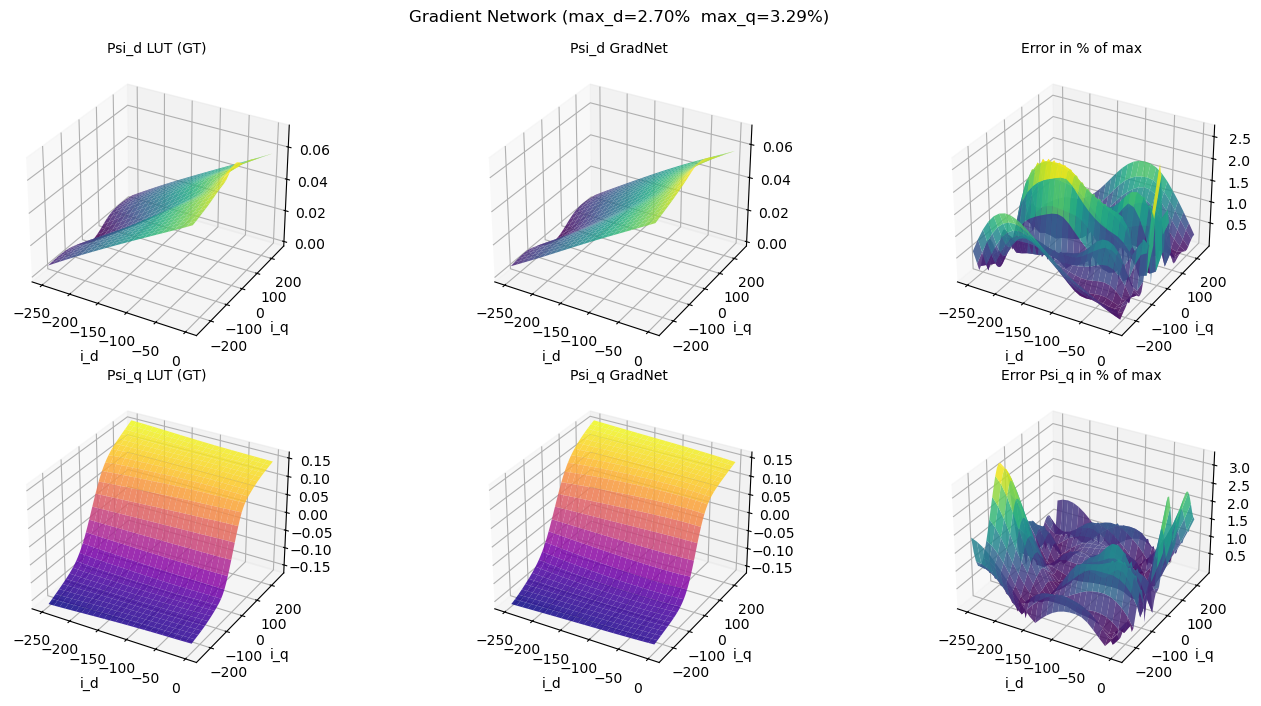

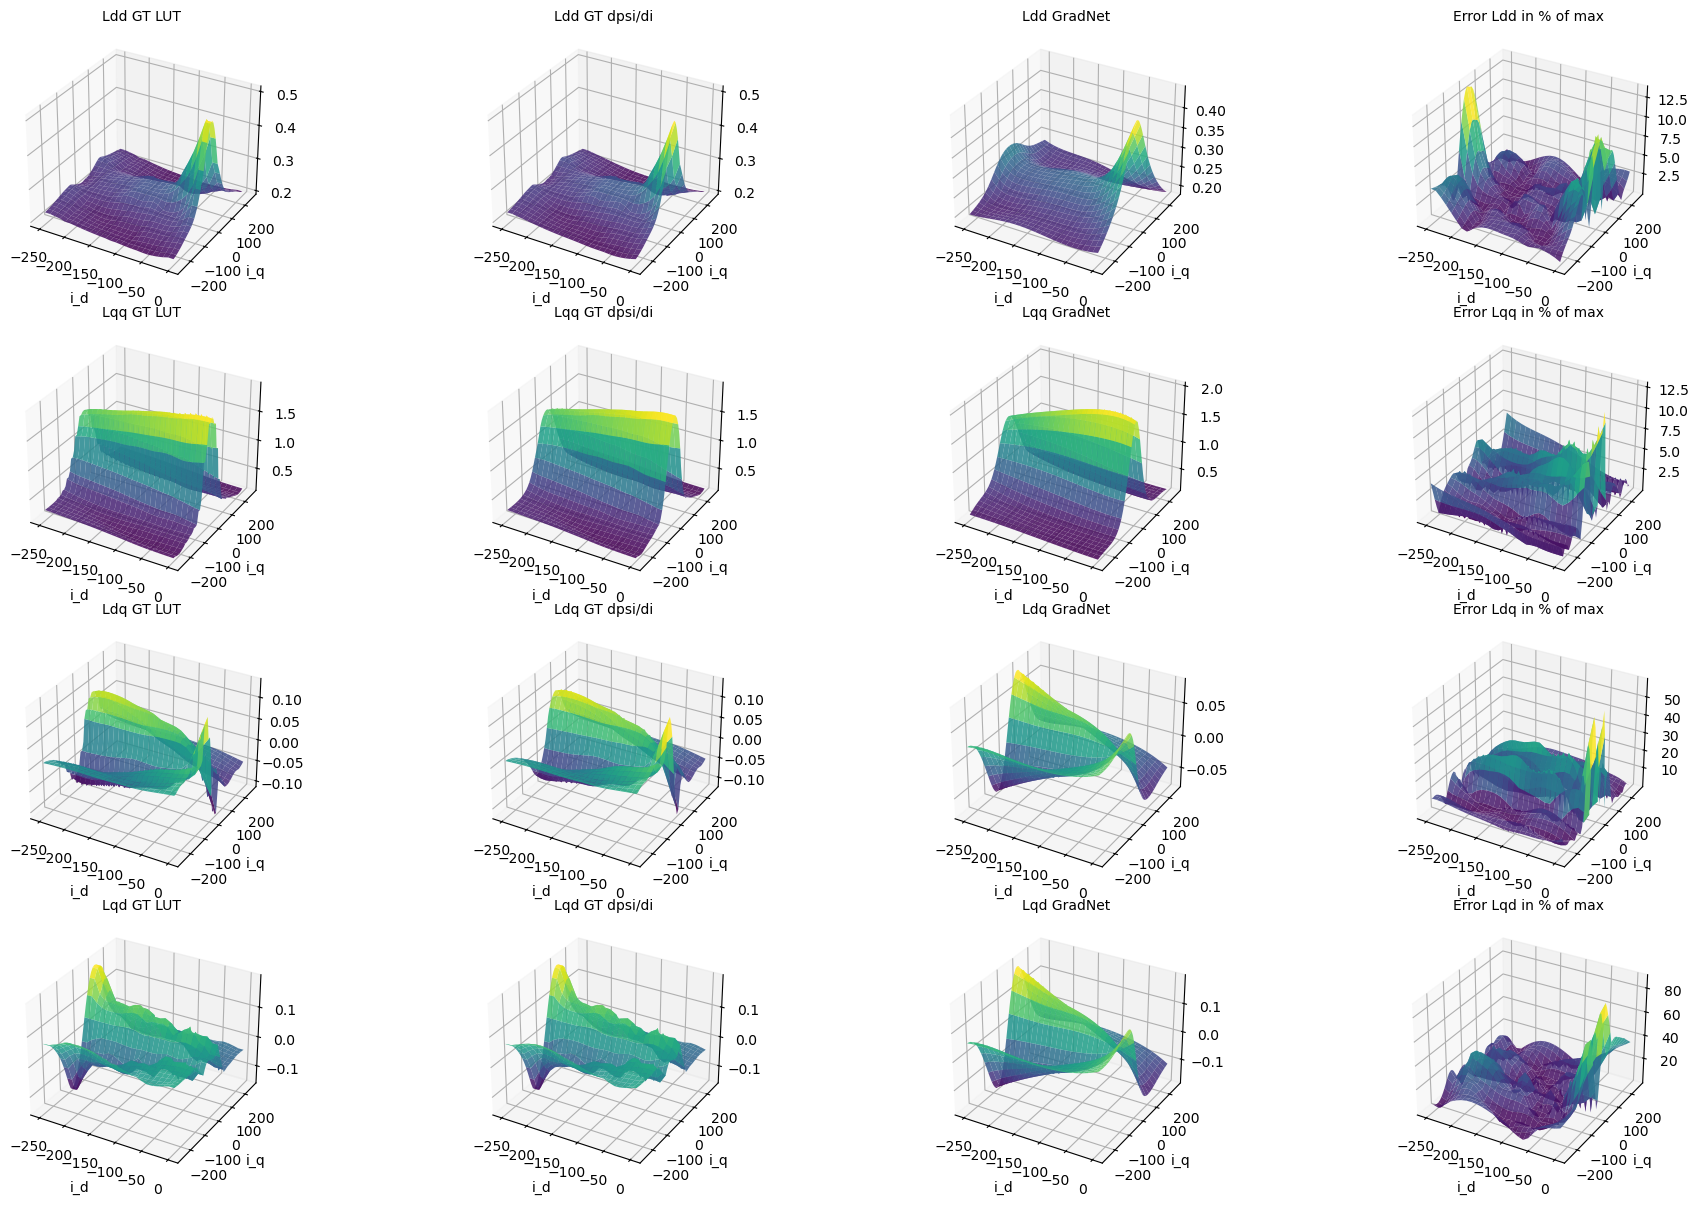

0.000102063714


In [22]:
plot_fit_comparison_gn(model_gn_psi_only, id_grid_A, iq_grid_A, luts_phys)

## Incorporate in env

In [30]:
from exciting_environments.pmsm import PMSM
from exciting_environments import EnvironmentRegistry
from exciting_environments.pmsm import MotorVariant


class SatPMSM_GradNet(PMSM):
    lut : eqx.Module
    norm: dict

    def __init__(self, lut, norm, **kwargs):
        super().__init__(**kwargs)
        self.lut  = lut
        self.norm = norm

    def _psi_dq(self, i_d, i_q):
        return self.lut.flux_physical(i_d, i_q)

    def _inductances(self, i_d, i_q):
        return self.lut.inductances_physical(i_d, i_q)

    def currents_to_torque_saturated(self, i_d, i_q):
        Psi_d, Psi_q = self._psi_dq(i_d, i_q)
        return 3 / 2 * self.env_properties.static_params.p * (Psi_d * i_q - Psi_q * i_d)

    def nonlinear_ode(self, t, y, args, action):
        i_d, i_q, eps = y
        static_params, omega_el = args
        u_dq = action(t)
        J_k  = jnp.array([[0, -1], [1, 0]])
        i_dq = jnp.array([i_d, i_q])

        psi_d, psi_q    = self._psi_dq(i_d, i_q)
        L_dd, L_qq, L_dq, L_qd = self._inductances(i_d, i_q)
        p_d = {"Psi_d": psi_d, "Psi_q": psi_q,
               "L_dd": L_dd, "L_qq": L_qq, "L_dq": L_dq, "L_qd": L_qd}

        L_diff     = jnp.array([[p_d["L_dd"], p_d["L_dq"]],
                                 [p_d["L_qd"], p_d["L_qq"]]])
        L_diff_inv = jnp.linalg.inv(L_diff)
        psi_dq     = jnp.array([p_d["Psi_d"], p_d["Psi_q"]])

        di_dq = (
            L_diff_inv @ (u_dq
                          - static_params.r_s * i_dq
                          - omega_el * J_k @ psi_dq)
        )
        return di_dq[0], di_dq[1], omega_el


sat_pmsm = SatPMSM_GradNet(
    model_gn_psi_only, norm,
    saturated=True,
    motor_variant=MotorVariant.BRUSA
)

pmsm = EnvironmentRegistry.PMSM.make(
    saturated=True, motor_variant=MotorVariant.BRUSA
)

# _, state_ref = pmsm_ref.reset()
# _, state_gn  = sat_pmsm_gn.reset()

# i_dqs_ref, i_dqs_gn = [], []
# act = jnp.array([0.03, 0.03])

# for _ in range(200):
#     obs, state_ref = pmsm_ref.step(state_ref, act)
#     i_dqs_ref.append(obs[:2])
#     obs, state_gn  = sat_pmsm_gn.step(state_gn, act)
#     i_dqs_gn.append(obs[:2])

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(jnp.array(i_dqs_ref)[:,0], jnp.array(i_dqs_ref)[:,1], label='Referenz (LUT)')
# ax.plot(jnp.array(i_dqs_gn )[:,0], jnp.array(i_dqs_gn )[:,1], '--', label='Gradient Network')
# ax.set_xlabel('id');  ax.set_ylabel('iq');  ax.legend()
# ax.set_title('Trajektorienvergleich')
# plt.tight_layout()
# plt.show()

In [31]:
import time
from functools import partial

In [32]:

def rollout_const(env, init_state, act, n_steps):
    def scan_fn(state, _):
        obs, next_state = env.step(state, act)
        loss = jnp.sum(obs[0:2] ** 2)
        return next_state, loss
    _, losses = jax.lax.scan(scan_fn, init_state, None, length=n_steps)
    return jnp.sum(losses)

def rollout_seq(env, init_state, acts, n_steps):
    def scan_fn(state, act):
        obs, next_state = env.step(state, act)
        loss = jnp.sum(obs[0:2] ** 2)
        return next_state, loss
    _, losses = jax.lax.scan(scan_fn, init_state, acts)
    return jnp.sum(losses)


@partial(jax.jit, static_argnums=(2,))
def fwd_const_pmsm(state, act, n_steps):
    return rollout_const(pmsm, state, act, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_const_sat(state, act, n_steps):
    return rollout_const(sat_pmsm, state, act, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_seq_pmsm(state, acts, n_steps):
    return rollout_seq(pmsm, state, acts, n_steps)

@partial(jax.jit, static_argnums=(2,))
def fwd_seq_sat(state, acts, n_steps):
    return rollout_seq(sat_pmsm, state, acts, n_steps)

@partial(jax.jit, static_argnums=(2,))
def bwd_const_pmsm(state, act, n_steps):
    return jax.grad(lambda a: rollout_const(pmsm, state, a, n_steps))(act)

@partial(jax.jit, static_argnums=(2,))
def bwd_const_sat(state, act, n_steps):
    return jax.grad(lambda a: rollout_const(sat_pmsm, state, a, n_steps))(act)

@partial(jax.jit, static_argnums=(2,))
def bwd_seq_pmsm(state, acts, n_steps):
    return jax.grad(lambda a: rollout_seq(pmsm, state, a, n_steps))(acts)

@partial(jax.jit, static_argnums=(2,))
def bwd_seq_sat(state, acts, n_steps):
    return jax.grad(lambda a: rollout_seq(sat_pmsm, state, a, n_steps))(acts)



key = jax.random.PRNGKey(0)
act_const = jnp.array([0.03, 0.03])
_, state     = pmsm.reset()
_, state_sat = sat_pmsm.reset()



print("Warm-up...")
for n_steps in [1, 10, 50, 100, 500]:
    acts_seq = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1)

    jax.block_until_ready(fwd_const_pmsm(state,     act_const, n_steps))
    jax.block_until_ready(fwd_const_sat( state_sat, act_const, n_steps))
    jax.block_until_ready(bwd_const_pmsm(state,     act_const, n_steps))
    jax.block_until_ready(bwd_const_sat( state_sat, act_const, n_steps))
    jax.block_until_ready(fwd_seq_pmsm(  state,     acts_seq,  n_steps))
    jax.block_until_ready(fwd_seq_sat(   state_sat, acts_seq,  n_steps))
    jax.block_until_ready(bwd_seq_pmsm(  state,     acts_seq,  n_steps))
    jax.block_until_ready(bwd_seq_sat(   state_sat, acts_seq,  n_steps))
print("Warm-up done.\n")



N = 50

def measure(fn, *args):
    t0 = time.perf_counter()
    for _ in range(N):
        out = fn(*args)
    jax.block_until_ready(jax.tree_util.tree_leaves(out))
    return (time.perf_counter() - t0) / N * 1000

sep    = "=" * 60
header = f"  {'n_steps':>8}    {'PMSM':>10}      {'SatPMSM':>10} " #{'Overhead':>8}

for label, fwd_p, fwd_s, bwd_p, bwd_s, use_seq in [
    # ("const action", fwd_const_pmsm, fwd_const_sat, bwd_const_pmsm, bwd_const_sat, False),
    ("seq actions",  fwd_seq_pmsm,   fwd_seq_sat,   bwd_seq_pmsm,   bwd_seq_sat,   True),
]:
    #print(sep)
    print(f"  {label}")
    print(sep)
    print(header)
    print("-" * 60)

    print("  ── Forward ──")
    for n_steps in [1, 10, 50, 100, 500]:
        acts = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1) if use_seq else act_const
        t_p = measure(fwd_p, state,     acts, n_steps)
        t_s = measure(fwd_s, state_sat, acts, n_steps)
        print(f"  n={n_steps:4d}       {t_p:8.3f} ms  {t_s:8.3f} ms") #{t_s/t_p:6.2f}x

    print("  ── Backward dloss/dacts ──")
    for n_steps in [1, 10, 50, 100, 500]:
        acts = jax.random.uniform(key, shape=(n_steps, 2), minval=-0.1, maxval=0.1) if use_seq else act_const
        t_p = measure(bwd_p, state,     acts, n_steps)
        t_s = measure(bwd_s, state_sat, acts, n_steps)
        print(f"  n={n_steps:4d}       {t_p:8.3f} ms  {t_s:8.3f} ms  ") #{t_s/t_p:6.2f}x

print(sep)

Warm-up...
Warm-up done.

  seq actions
   n_steps          PMSM         SatPMSM 
------------------------------------------------------------
  ── Forward ──
  n=   1          0.291 ms     0.198 ms
  n=  10          1.820 ms     0.836 ms
  n=  50          6.389 ms     3.242 ms
  n= 100         12.741 ms     6.156 ms
  n= 500         63.595 ms    29.554 ms
  ── Backward dloss/dacts ──
  n=   1          0.089 ms     0.086 ms  
  n=  10          3.772 ms     1.439 ms  
  n=  50         17.818 ms     6.711 ms  
  n= 100         35.359 ms    13.390 ms  
  n= 500        176.778 ms    66.603 ms  
